In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from optimal_granularity import get_optimal_granularity
from utils import load_shapefile_points, save_results_to_csv
from visualization import make_aligned_grid, plot_grid, plot_heatmap
import pathlib

# Chicago

In [2]:
shapefile_path = "../data/chicago/points/chicago_crimes.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [3]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/chicago/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

Optimal granularity: OptimizeReturn(optimal_tradeoff=np.float64(0.24915136373869487), optimal_scale=np.float64(1141.1266157512434), tradeoff_values={'1141.1266157512434': OptimizeDictReturn(uniformity=np.float64(0.545), robustness=np.float64(0.45715846557558687), tradeoff=np.float64(0.24915136373869487)), '4238.470287076047': OptimizeDictReturn(uniformity=np.float64(0.36), robustness=np.float64(0.5843639853990854), tradeoff=np.float64(0.21037103474367075)), '7335.81395840085': OptimizeDictReturn(uniformity=np.float64(0.225), robustness=np.float64(0.735978203827934), tradeoff=np.float64(0.16559509586128515)), '10433.157629725654': OptimizeDictReturn(uniformity=np.float64(0.105), robustness=np.float64(0.8417939383884666), tradeoff=np.float64(0.088388363530789)), '13530.501301050457': OptimizeDictReturn(uniformity=np.float64(0.075), robustness=np.float64(0.8953405436363226), tradeoff=np.float64(0.0671505407727242)), '16627.84497237526': OptimizeDictReturn(uniformity=np.float64(0.005), rob

### Visualization

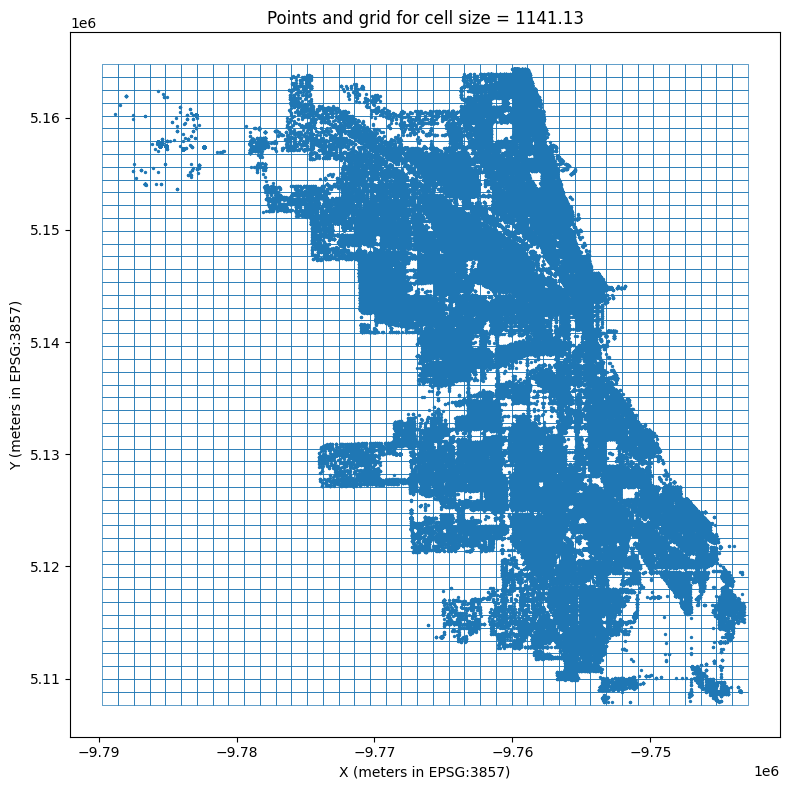

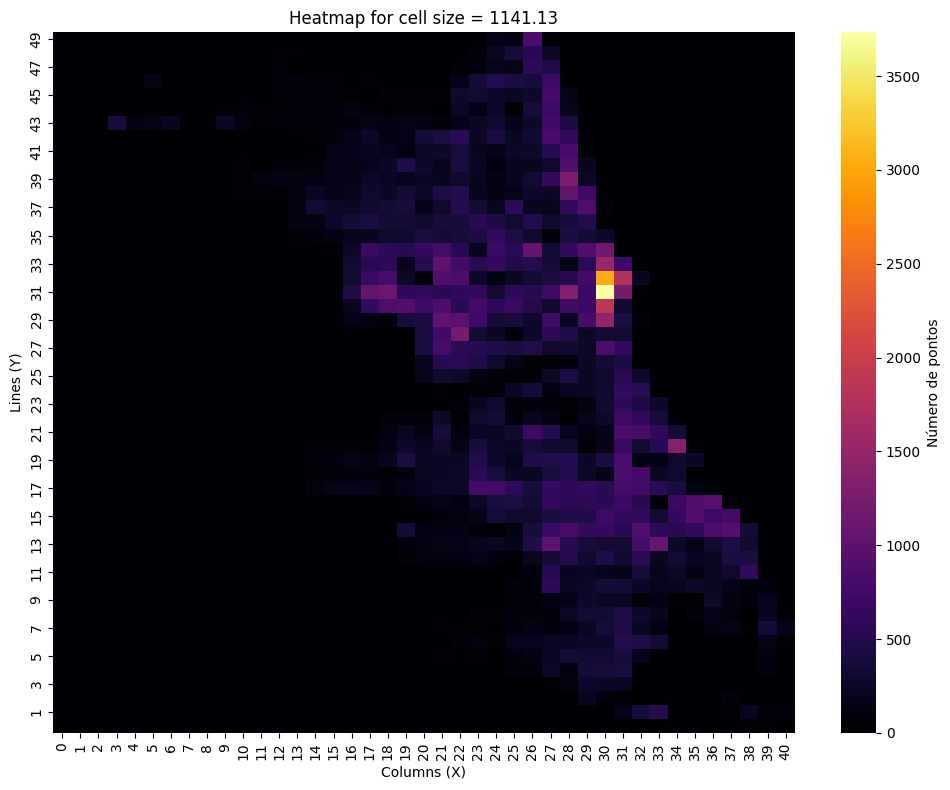

HeatmapStats(mean_all_cells=np.float64(121.64439024390244), mean_nonzero_cells=280.1921348314607)


In [5]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

# Burglaries

In [7]:
shapefile_path = "../data/burglaries/burglary.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [8]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=12,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/burglary/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

Optimal granularity: OptimizeReturn(optimal_tradeoff=np.float64(0.46315405178822827), optimal_scale=np.float64(549.0833883878422), tradeoff_values={'549.0833883878422': OptimizeDictReturn(uniformity=np.float64(0.72), robustness=np.float64(0.6432695163725393), tradeoff=np.float64(0.46315405178822827)), '1497.5001501486604': OptimizeDictReturn(uniformity=np.float64(0.305), robustness=np.float64(0.7536723781460579), tradeoff=np.float64(0.22987007533454765)), '2445.9169119094786': OptimizeDictReturn(uniformity=np.float64(0.24), robustness=np.float64(0.838843051624699), tradeoff=np.float64(0.20132233238992775)), '3394.3336736702972': OptimizeDictReturn(uniformity=np.float64(0.13), robustness=np.float64(0.9075160568041063), tradeoff=np.float64(0.11797708738453382)), '4342.750435431115': OptimizeDictReturn(uniformity=np.float64(0.085), robustness=np.float64(0.9430658299148398), tradeoff=np.float64(0.08016059554276139)), '5291.167197191934': OptimizeDictReturn(uniformity=np.float64(0.015), rob

In [9]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=12,
    signif=0.99,
    uniformity_method="clark_evans",
    # uniformity_num_random_quadrats_per_scale=200, # clark_evans does not need this
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/burglary/results-ce.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

Optimal granularity: OptimizeReturn(optimal_tradeoff=np.float64(0.16484120341482952), optimal_scale=np.float64(549.0833883878422), tradeoff_values={'549.0833883878422': OptimizeDictReturn(uniformity=np.float64(0.255), robustness=np.float64(0.6464360918228609), tradeoff=np.float64(0.16484120341482952)), '1497.5001501486604': OptimizeDictReturn(uniformity=np.float64(0.01), robustness=np.float64(0.7483915801979151), tradeoff=np.float64(0.0074839158019791505)), '2445.9169119094786': OptimizeDictReturn(uniformity=np.float64(0.015), robustness=np.float64(0.8409538161843009), tradeoff=np.float64(0.012614307242764513)), '3394.3336736702972': OptimizeDictReturn(uniformity=np.float64(0.005), robustness=np.float64(0.9098008125327754), tradeoff=np.float64(0.004549004062663877)), '4342.750435431115': OptimizeDictReturn(uniformity=np.float64(0.01), robustness=np.float64(0.9427495425060064), tradeoff=np.float64(0.009427495425060065)), '5291.167197191934': OptimizeDictReturn(uniformity=np.float64(0.00

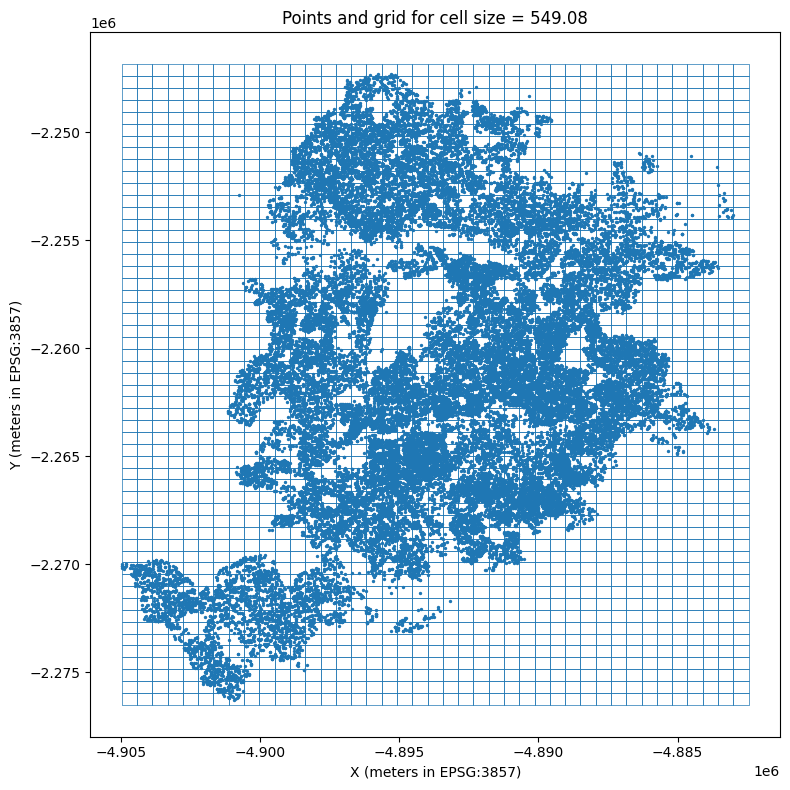

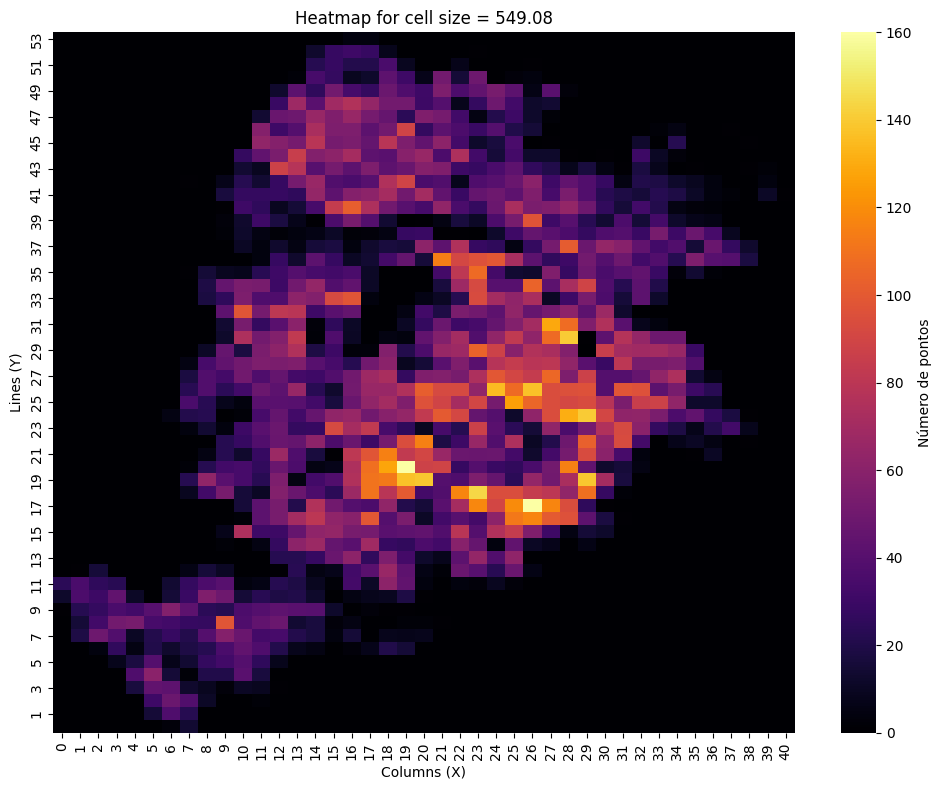

HeatmapStats(mean_all_cells=np.float64(20.12646793134598), mean_nonzero_cells=39.679430097951915)


In [10]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

# Fires confirmed 2023 Minneapolis

In [11]:
shapefile_path = "../data/fires_confirmed_2023_minneapolis/Fires_Confirmed_2023.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [12]:
mean_x = np.mean(coords[:, 0])
mean_y = np.mean(coords[:, 1])

dist_from_mean = np.sqrt((coords[:, 0] - mean_x) ** 2 + (coords[:, 1] - mean_y) ** 2)

outlier_indices = np.argsort(dist_from_mean)[-3:]
outlier_coords = coords[outlier_indices]

coords_clean = np.delete(coords, outlier_indices, axis=0)
gdf_coords_clean = gdf_coords.drop(gdf_coords.index[outlier_indices]).reset_index(drop=True)

coords = coords_clean
gdf_coords = gdf_coords_clean

In [13]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/fires-minneapolis/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

Optimal granularity: OptimizeReturn(optimal_tradeoff=np.float64(0.5429867652934052), optimal_scale=np.float64(1389.2677220036894), tradeoff_values={'374.03361746253177': OptimizeDictReturn(uniformity=np.float64(0.98), robustness=np.float64(0.4463263121812663), tradeoff=np.float64(0.43739978593764095)), '1389.2677220036894': OptimizeDictReturn(uniformity=np.float64(0.825), robustness=np.float64(0.6581657761132185), tradeoff=np.float64(0.5429867652934052)), '2404.501826544847': OptimizeDictReturn(uniformity=np.float64(0.625), robustness=np.float64(0.7657054430426004), tradeoff=np.float64(0.47856590190162523)), '3419.7359310860047': OptimizeDictReturn(uniformity=np.float64(0.345), robustness=np.float64(0.8069544267716947), tradeoff=np.float64(0.27839927723623464)), '4434.970035627162': OptimizeDictReturn(uniformity=np.float64(0.12), robustness=np.float64(0.8427710666179671), tradeoff=np.float64(0.10113252799415605)), '5450.20414016832': OptimizeDictReturn(uniformity=np.float64(0.04), robu

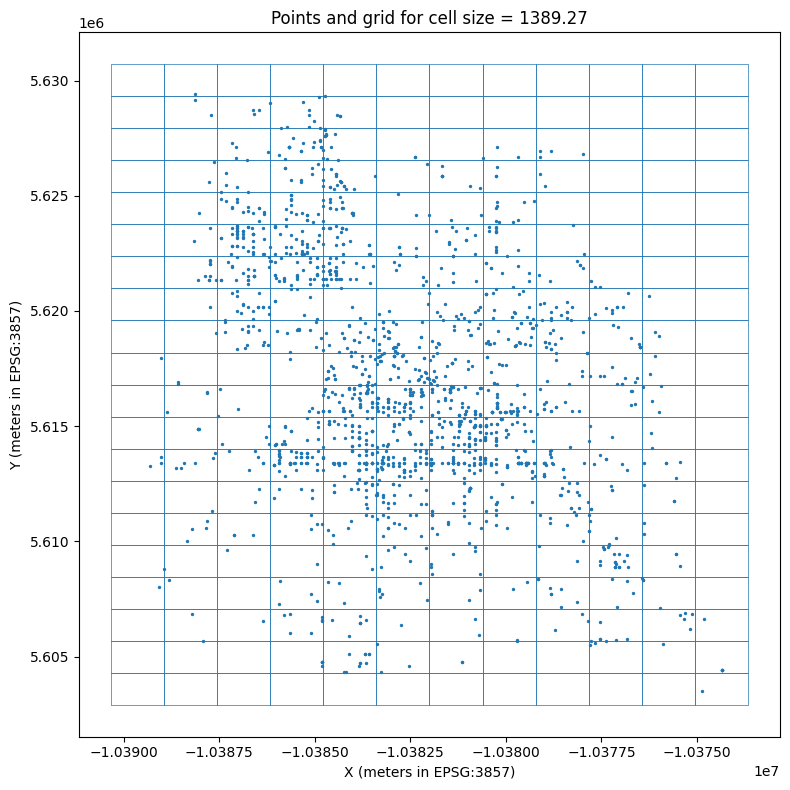

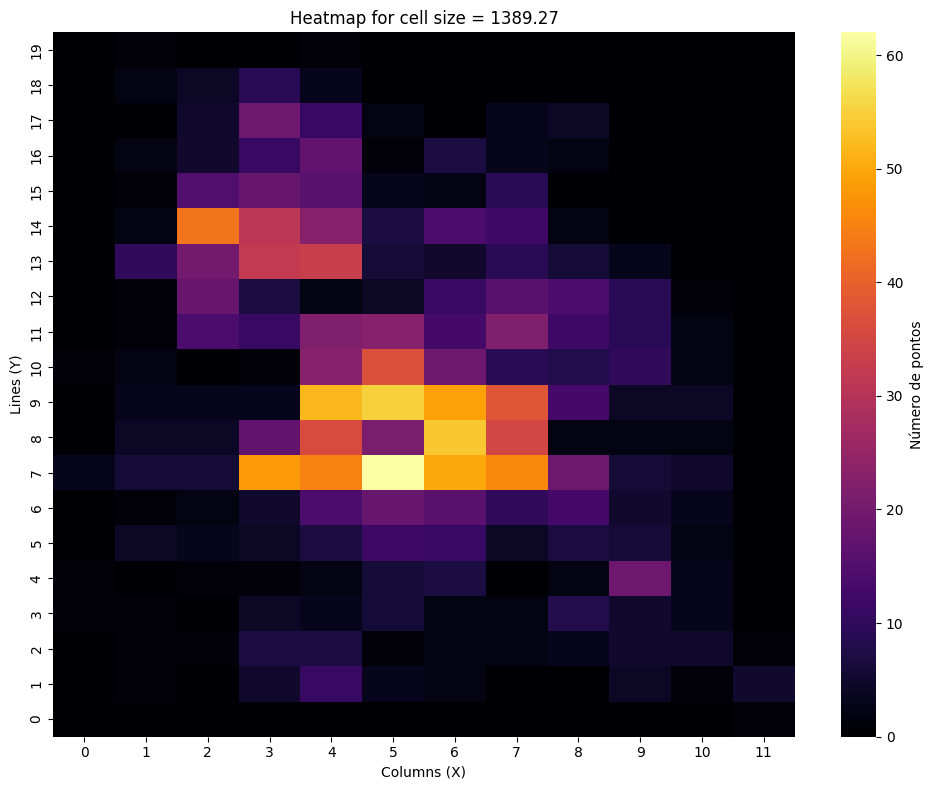

HeatmapStats(mean_all_cells=np.float64(7.279166666666667), mean_nonzero_cells=10.652439024390244)


In [14]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

In [15]:
gdf_coords.shape

(1747, 25)

# Public Incidents Minneapolis

In [16]:
shapefile_path = "../data/public_incidents_minneapolis/Public_311_Incidents_2020.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [17]:
mean_x = np.mean(coords[:, 0])
mean_y = np.mean(coords[:, 1])

dist_from_mean = np.sqrt((coords[:, 0] - mean_x) ** 2 + (coords[:, 1] - mean_y) ** 2)

outlier_indices = np.argsort(dist_from_mean)[-19034:]
outlier_coords = coords[outlier_indices]

coords_clean = np.delete(coords, outlier_indices, axis=0)
gdf_coords_clean = gdf_coords.drop(gdf_coords.index[outlier_indices]).reset_index(drop=True)

coords = coords_clean
gdf_coords = gdf_coords_clean

In [18]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/public-incidents-minneapolis/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

Optimal granularity: OptimizeReturn(optimal_tradeoff=np.float64(0.1957107087222825), optimal_scale=np.float64(361.4024750500332), tradeoff_values={'361.4024750500332': OptimizeDictReturn(uniformity=np.float64(0.3), robustness=np.float64(0.652369029074275), tradeoff=np.float64(0.1957107087222825)), '1342.3520501858375': OptimizeDictReturn(uniformity=np.float64(0.06), robustness=np.float64(0.8215502081408624), tradeoff=np.float64(0.04929301248845174)), '2323.301625321642': OptimizeDictReturn(uniformity=np.float64(0.02), robustness=np.float64(0.8578679234393953), tradeoff=np.float64(0.017157358468787905)), '3304.2512004574464': OptimizeDictReturn(uniformity=np.float64(0.0), robustness=np.float64(0.8862151026518289), tradeoff=np.float64(0.0)), '4285.200775593251': OptimizeDictReturn(uniformity=np.float64(0.0), robustness=np.float64(0.8953000855824176), tradeoff=np.float64(0.0)), '5266.1503507290545': OptimizeDictReturn(uniformity=np.float64(0.0), robustness=np.float64(0.8966487360040987), 

In [19]:
gdf_coords[:-10]

,CASEID,SUBJECTNAM,REASONNAME,TYPENAME,TITLE,OPENEDDATE,CASESTATUS,CLOSEDDATE,XCOORD,YCOORD,LastUpdate,geometry
0,2.010000e+11,Utilities Related,Sewer & Storm Drain,Sewer Issues,Sewer Issues,2020-05-11,0,2020-05-14,-1.038109e+07,5.609315e+06,2021-03-10,POINT (-10381092.822 5609315.423)
1,2.010000e+11,Property,Private Property,Rental License Followup,Rental License Followup,2020-05-11,0,2020-05-22,-1.038756e+07,5.606465e+06,2021-03-10,POINT (-10387563.944 5606464.789)
2,2.010000e+11,Property,Private Property,Rental License Followup,Rental License Followup,2020-05-11,0,2020-05-22,-1.038753e+07,5.619335e+06,2021-03-10,POINT (-10387528.392 5619335.171)
3,2.010000e+11,Property,Private Property,Exterior Nuisance Complaint,Exterior Nuisance Complaint,2020-05-11,0,2020-05-12,-1.038350e+07,5.604607e+06,2021-03-10,POINT (-10383496.771 5604606.643)
4,2.010000e+11,Permits / Licensing,Commercial / Business Licensing,Licensing Complaint,Licensing Complaint,2020-05-11,0,2020-05-12,-1.038433e+07,5.616484e+06,2021-03-10,POINT (-10384325.252 5616484.275)
...,...,...,...,...,...,...,...,...,...,...,...,...
75020,2.010001e+11,Sidewalks,Complaints,Sidewalk Structural Complaint,Sidewalk Structural Complaint,2020-08-18,0,2020-08-31,-1.038096e+07,5.612968e+06,2021-03-10,POINT (-10380960.778 5612967.938)
75021,2.010001e+11,Streets,Lighting,Xcel Street Light Trouble,Xcel Street Light Trouble,2020-08-18,0,2020-08-18,-1.038492e+07,5.623727e+06,2021-03-10,POINT (-10384915.643 5623726.983)
75022,2.010001e+11,Property,Development Review,Development Coordinator,Development Coordinator,2020-08-18,0,2020-08-18,-1.038382e+07,5.607637e+06,2021-03-10,POINT (-10383822.278 5607636.533)
75023,2.010001e+11,Streets,Street Maintenance,Debris in the Street or Alley,Debris in the Street or Alley,2020-08-18,0,2020-08-19,-1.038734e+07,5.627580e+06,2021-03-10,POINT (-10387339.716 5627580.14)


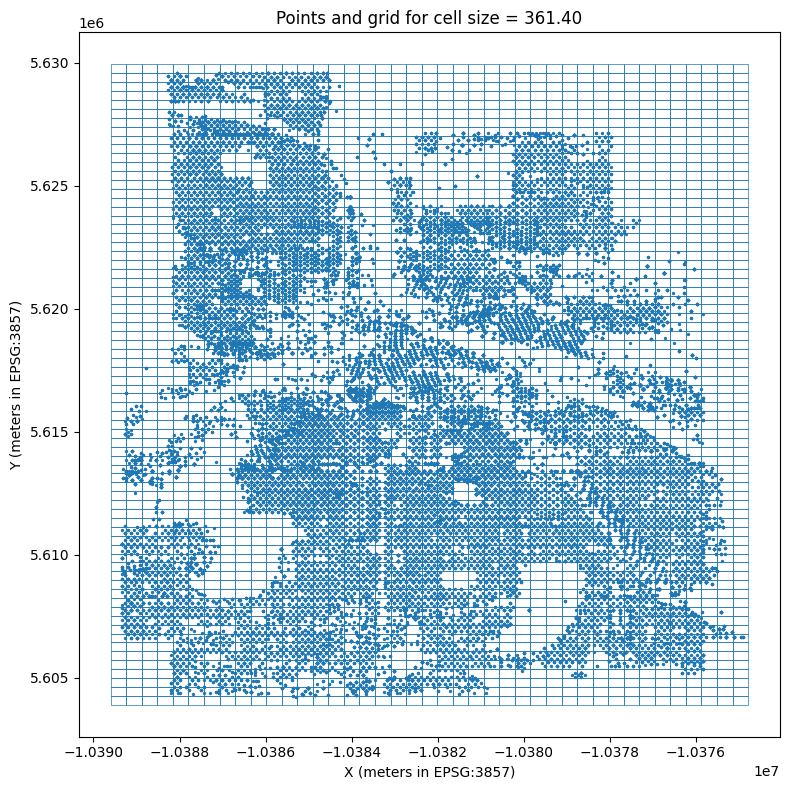

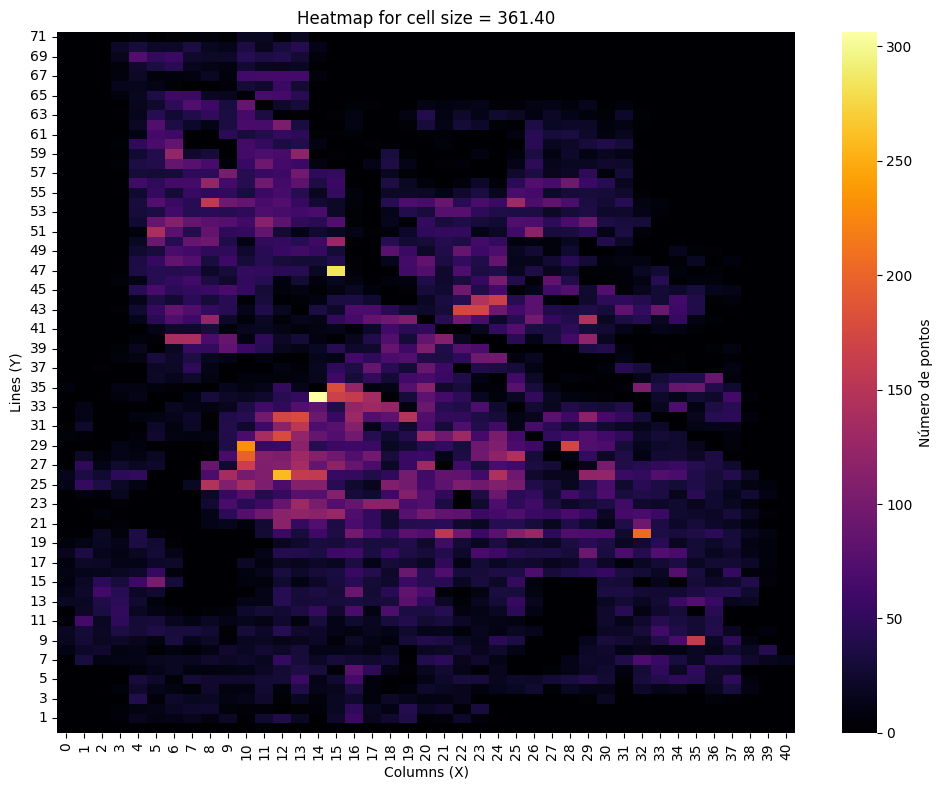

HeatmapStats(mean_all_cells=np.float64(25.418360433604335), mean_nonzero_cells=36.05718404613167)


In [20]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)